In [1]:
!pip install profet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.9/84.9 kB 8.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.9/82.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.9 MB/s eta 0:00:00
  Created wheel 

In [4]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [6]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# ── Preprocessing ────────────────────────────────────────────────────────
df = pd.read_csv("donnees_synthetiques_tollxpress_benin_2023-2024.csv")
df["Date_Heure"] = pd.to_datetime(df["Date_Heure"])

agg = (
    df.groupby(df["Date_Heure"].dt.floor("h"))
      .agg(y=("ID_transaction", "count"))
      .reset_index()
      .rename(columns={"Date_Heure": "ds"})
)



In [7]:
agg

,ds,y
0,2023-01-01 01:00:00,2
1,2023-01-01 05:00:00,1
2,2023-01-01 06:00:00,7
3,2023-01-01 07:00:00,13
4,2023-01-01 08:00:00,17
...,...,...
15801,2024-12-31 18:00:00,18
15802,2024-12-31 19:00:00,17
15803,2024-12-31 20:00:00,11
15804,2024-12-31 21:00:00,9


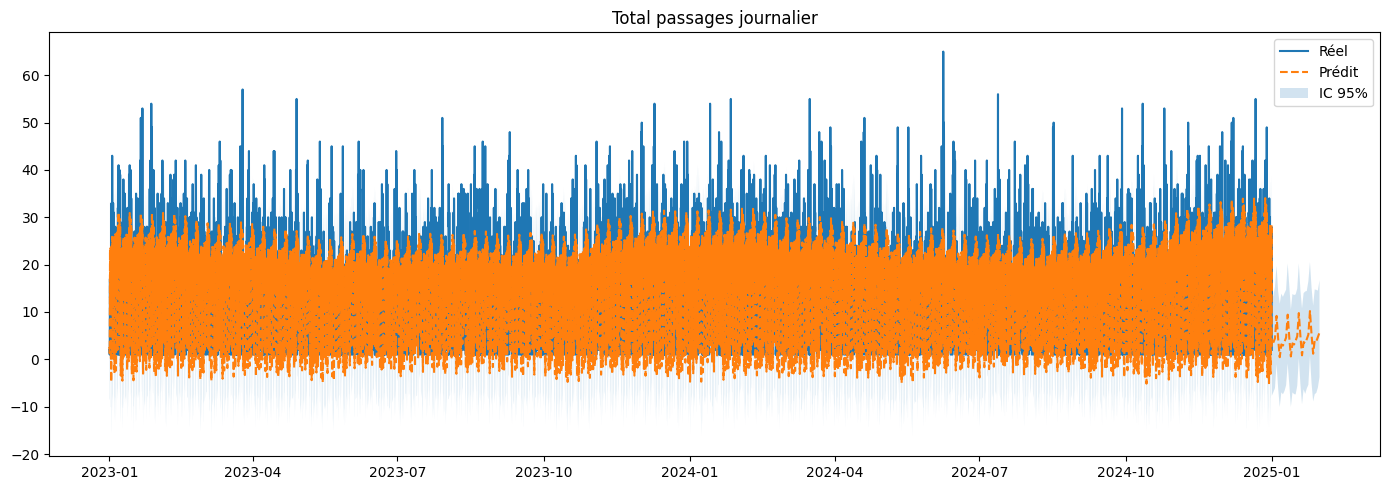

In [9]:
# ── Modèle passages ──────────────────────────────────────────────────────
model = Prophet(seasonality_mode="multiplicative",
                     weekly_seasonality=True,
                     yearly_seasonality=True,
                     interval_width=0.95)
model.fit(agg)
f_passages = model.predict(model.make_future_dataframe(periods=30))

# ── Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(14, 5)) # Changed to 1 subplot for now
axes.plot(agg["ds"], agg["y"], label="Réel")
axes.plot(f_passages["ds"], f_passages["yhat"], label="Prédit", linestyle="--")
axes.fill_between(f_passages["ds"], f_passages["yhat_lower"],
                     f_passages["yhat_upper"], alpha=0.2, label="IC 95%")
axes.set_title("Total passages journalier"); axes.legend()

# The 'montant' model and plot are removed as the 'agg' DataFrame does not contain 'montant' data.
# If you wish to forecast 'montant', you would need to create a separate aggregated DataFrame for it.

plt.tight_layout()
plt.savefig("prophet_global.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
print("Predictions for the next 30 days:")
print(f_passages[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))

Predictions for the next 30 days:
                       ds       yhat  yhat_lower  yhat_upper
15806 2025-01-01 22:00:00   3.575666   -6.946237   13.435228
15807 2025-01-02 22:00:00   4.443669   -6.074420   15.276437
15808 2025-01-03 22:00:00   9.180790   -0.988819   19.752014
15809 2025-01-04 22:00:00   4.366442   -6.107779   14.323978
15810 2025-01-05 22:00:00   0.445362  -10.073756   11.735818
15811 2025-01-06 22:00:00   3.144052   -6.970334   13.874524
15812 2025-01-07 22:00:00   2.902777   -7.378621   13.189231
15813 2025-01-08 22:00:00   3.708238   -6.687922   13.995799
15814 2025-01-09 22:00:00   4.612661   -5.474466   14.705186
15815 2025-01-10 22:00:00   9.435335   -0.890733   20.265884
15816 2025-01-11 22:00:00   4.573054   -5.262219   15.548250
15817 2025-01-12 22:00:00   0.613448  -10.045984   10.534040
15818 2025-01-13 22:00:00   3.360980   -6.978171   13.806708
15819 2025-01-14 22:00:00   3.126655   -7.341596   13.578337
15820 2025-01-15 22:00:00   3.951788   -7.416813   

In [12]:
dfpredicted=pd.DataFrame(f_passages[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30))

In [13]:
dfpredicted

,ds,yhat,yhat_lower,yhat_upper
15806,2025-01-01 22:00:00,3.575666,-6.946237,13.435228
15807,2025-01-02 22:00:00,4.443669,-6.074420,15.276437
15808,2025-01-03 22:00:00,9.180790,-0.988819,19.752014
15809,2025-01-04 22:00:00,4.366442,-6.107779,14.323978
15810,2025-01-05 22:00:00,0.445362,-10.073756,11.735818
15811,2025-01-06 22:00:00,3.144052,-6.970334,13.874524
15812,2025-01-07 22:00:00,2.902777,-7.378621,13.189231
15813,2025-01-08 22:00:00,3.708238,-6.687922,13.995799
15814,2025-01-09 22:00:00,4.612661,-5.474466,14.705186
15815,2025-01-10 22:00:00,9.435335,-0.890733,20.265884


In [11]:
import plotly.express as px

In [15]:
fig = px.line(dfpredicted, x='ds', y='yhat', title=' High Over Time')

# Add a range slider to the layout
fig.update_layout(
    xaxis_rangeslider_visible=True
)

fig.show()